## Search and Scoring for Learning a Bayesian Network

##### Ángel Martín Ramírez Rabelo

Fecha: 26 de junio de 2025

El objetivo de este proyecto es desarrollar un algoritmo de tipo búsqueda y puntuación que sea capaz de aprender una red bayesiana.

### Representación de las soluciones: Matriz de adyacencia

Es una representación matricial de un grafo en la que las filas y columnas representan los vértices del grafo, y los elementos de la matriz indican si existe una arista entre dos vértices. De esta manera es posible representar la información sobre las conexiones entre los nodos de un grafo de forma binaria. 

- El valor en la posición (i, j) de la matriz indica si existe una arista que va del vértice i al vértice j. Tenemos entonces una matriz $𝐴$ de tamaño $𝑛×𝑛$ tal que:

    - $𝐴[𝑖][𝑗]=1$ si hay una arista de $𝑋𝑖→𝑋𝑗$.

    - $𝐴[𝑖][𝑗]=0$ si no hay arista

- En grafos no dirigidos, la matriz de adyacencia es simétrica (si hay una arista entre i y j, también hay una entre j e i). En grafos dirigidos, la matriz no tiene por qué ser simétrica, ya que las aristas tienen dirección.

- Con la restricción de que el grafo debe ser acíclico.

In [5]:
#%pip install networkx matplotlib

### Matriz de adyacencia y vizualización de poblaciones

In [83]:
#Funciones para construir y visualizar poblaciones de DAGs (Grafos Acíclicos Dirigidos)
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import numpy as np
import random
import math


def visualize_population2(population, variable_names=None, scores=None, figsize=(16, 12)):
    n_individuals = len(population)
    n_vars = population[0].shape[0]

    if variable_names is None:
        variable_names = [f"X{i}" for i in range(n_vars)]

    # Calcular cuadrícula de subplots (rectangular, casi cuadrada)
    n_cols = math.ceil(math.sqrt(n_individuals))
    n_rows = math.ceil(n_individuals / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)  # Asegura que sea plano (1D)

    for i, ax in enumerate(axes):
        if i >= n_individuals:
            ax.axis('off')
            continue

        adj_matrix = population[i]
        G = nx.DiGraph()
        G.add_nodes_from(variable_names)
        for u in range(n_vars):
            for v in range(n_vars):
                if adj_matrix[u, v] == 1:
                    G.add_edge(variable_names[u], variable_names[v])

        pos = nx.shell_layout(G)  #, seed=42 misma posición para cada DAG
        nx.draw_networkx(
            G, pos, ax=ax, with_labels=True,
            node_color="skyblue", node_size=900,
            font_size=10, arrows=True, edge_color='gray'
        )

        score_text = f" | Score: {scores[i]:.2f}" if scores else ""
        ax.set_title(f"Individuo {i+1}{score_text}", fontsize=11)
        ax.axis('off')

    # Ajustar el layout para que no se superpongan los subplots 
    plt.tight_layout(pad=2.5)
    plt.subplots_adjust(wspace=0.4, hspace=0.6)
    plt.show()


def plot_dag(adj_matrix, variable_names=None, title="DAG aprendido"):
    G = nx.DiGraph()

    n = adj_matrix.shape[0]
    labels = variable_names if variable_names else [str(i) for i in range(n)]

    # Agregar nodos y aristas
    for i in range(n):
        G.add_node(i, label=labels[i])
    for i in range(n):
        for j in range(n):
            if adj_matrix[i, j] == 1:
                G.add_edge(i, j)

    try:
        # Layout jerárquico si está disponible
        pos = nx.shell_layout(G) 
        #pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except:
        # Si no hay pygraphviz, usar layout alternativo
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(5, 3))
    nx.draw(G, pos, with_labels=True, labels={i: labels[i] for i in G.nodes()},
            node_color='lightblue', node_size=1000, font_size=7, arrowsize=15)
    plt.title(title)
    #plt.tight_layout()
    plt.show()



def random_dag(n_vars, edge_prob=0.3):
    """Genera una matriz de adyacencia acíclica aleatoria."""
    A = np.zeros((n_vars, n_vars), dtype=int)
    # Creamos una permutación aleatoria de nodos (orden topológico)
    nodes = list(range(n_vars))
    random.shuffle(nodes)
    # Solo permitimos aristas hacia adelante en este orden → garantiza aciclicidad
    for i in range(n_vars):
        for j in range(i+1, n_vars):
            if random.random() < edge_prob:
                A[nodes[i], nodes[j]] = 1
    return A

def generate_initial_population(pop_size, n_vars):
    return [random_dag(n_vars) for _ in range(pop_size)]


array([[0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0]])

### Criterio de Búsqueda o Función de costo: BIC

$$BIC(𝐺)=log𝑃(𝐷∣𝐺,\hat\theta)−\frac{k}{2}\log𝑁$$

Donde:

𝐺 = estructura de red (DAG)

$\hat\theta$ = parámetros ajustados por verosimilitud (probabilidades condicionales)

𝐷 = datos observados

𝑁 = número de observaciones

𝑘 = número de parámetros libres del modelo (esto depende de la cantidad de padres por nodo y el número de estados posibles)

Supuestos de la función para estimar BIC:

- Las variables son discretas (p. ej. binarias: 0 o 1).

- Los datos están en un DataFrame de pandas.

- Las redes se representan como matrices de adyacencia.

Metodología:

1. Para cada nodo $𝑋_𝑖$, identifica sus padres en la red.

2. Cuenta cuántas combinaciones posibles hay de los padres (configuraciones parentales).

3. Para cada configuración, cuenta las frecuencias de valores de $𝑋_𝑖$.

4. Estima la verosimilitud y el número de parámetros 𝑘.

In [177]:
#Implementacion BIC para evaluar DAGs
def bic_score(data: pd.DataFrame, adj_matrix: np.ndarray) -> float:
    n_vars = adj_matrix.shape[0]
    N = len(data)
    total_log_likelihood = 0
    total_params = 0

    for child_idx in range(n_vars):
        child = data.columns[child_idx]

        # Identificar padres de este nodo
        parent_idxs = np.where(adj_matrix[:, child_idx] == 1)[0]
        parents = [data.columns[i] for i in parent_idxs]

        # Obtener tabla de frecuencias condicionales
        if parents:
            # Agrupar por padres y hijo, contar ocurrencias
            counts = data.groupby(parents + [child], observed=True).size().reset_index(name='count')
            parent_counts = data.groupby(parents, observed=True).size().reset_index(name='total')

            # Unir para obtener proporciones condicionales
            merged = counts.merge(parent_counts, on=parents)
            merged['prob'] = merged['count'] / merged['total']

            # Log-likelihood
            log_likelihood = (merged['count'] * np.log(merged['prob'])).sum()

            # Número de parámetros = (#config padres) * (#valores posibles de hijo - 1)
            r_i = data[child].nunique()
            q_i = np.prod([data[p].nunique() for p in parents])
            params = np.float64(q_i) * (np.float64(r_i) - 1)
            #params = q_i * (r_i - 1)

        else:
            # Nodo sin padres: distribución marginal
            counts = data[child].value_counts()
            probs = counts / counts.sum()
            log_likelihood = (counts * np.log(probs)).sum()
            params = data[child].nunique() - 1

        total_log_likelihood += log_likelihood
        total_params += params

    bic = total_log_likelihood - 0.5 * total_params * np.log(N)
    return bic

## Optimización de la Red: Algoritmo genético.

🧬 Arquitectura del Algoritmo Genético para DAGs

🔁 Ciclo general:

- Inicialización: población aleatoria de DAGs

- Evaluación: puntuar cada individuo con BIC

- Selección: elegir individuos para reproducirse

- Crossover: combinar 2 DAGs para generar hijos

- Mutación: modificar aristas manteniendo aciclicidad

- Reemplazo: nueva generación

- Repetir hasta convergencia o max generaciones

$\textbf{Funciones desarrolladas}$

1. evaluate_population(población, datos) → lista de BICs

2. select_parents(población, scores) → padres para cruzar

3. crossover(parent1, parent2) → hijo DAG

4. mutate(dag, prob=0.1) → DAG mutado sin ciclos

5. is_acyclic(adj_matrix) → validador para mutación

6. evolve(...) → bucle evolutivo completo

#### Evaluate Population and Parents Selection

In [5]:
#1. Evaluar una población de DAGs con BIC
#   - population: lista de matrices de adyacencia (DAGs)
def evaluate_population(population, data):
    return [bic_score(data, ind) for ind in population]

- Para la selección de padres usaremos selección proporcional al BIC, también conocida como selección por ruleta (roulette wheel selection).

Dado un conjunto de individuos y sus puntuaciones BIC:

- Seleccionar individuos con probabilidad proporcional a su score. Cada individuo tiene una probabilidad de ser elegido proporcional a su "fitness" (es decir, a su puntuación).

$$Prob(i)=\frac{fitness_i}{\sum_j fitness_j} $$

- Como el BIC puede ser negativo, primero debemos normalizarlo.

$$fitness_i=BIC_i - min(BIC)+\epsilon$$

In [6]:
#2. Select Parents
def select_parents(population, scores, n_parents=2):
    # Convertir BICs en valores positivos de fitness
    min_score = min(scores)
    epsilon = 1.0
    fitness = [s - min_score + epsilon for s in scores]

    # Convertir a distribución de probabilidad
    total = sum(fitness)
    probs = [f / total for f in fitness]

    # Seleccionar índices de padres
    selected_indices = np.random.choice(len(population), size=n_parents, p=probs, replace=False)
    parents = [population[i] for i in selected_indices]
    return parents

In [7]:
#Ejemplo de uso de evaluación y selección de padres
parents = select_parents(pop, scores, n_parents=2)
print("Dos padres seleccionados:")
for i, p in enumerate(parents):
    print(f"Padre {i+1}:\n{p}")

Dos padres seleccionados:
Padre 1:
[[0 0 0 0 1]
 [0 0 0 0 0]
 [1 0 0 1 0]
 [0 1 0 0 0]
 [0 0 0 0 0]]
Padre 2:
[[0 0 0 1 0]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]]


#### Cross-Over (con máscara binaria aleatoria para DAGs )

Dado un par de grafos acíclicos dirigidos (DAGs) representados por matrices de adyacencia $A^{(1)}$ y $A^{(2)} \in \{0,1\}^{n \times n}$, se define un operador de cruza (crossover) utilizando una \textbf{máscara binaria aleatoria} $M \in \{0,1\}^{n \times n}$.

\paragraph{Definición del hijo:}
La matriz de adyacencia del hijo $A^{(h)}$ se construye elemento a elemento como:

$$
A^{(h)}_{ij} = 
\begin{cases}
A^{(1)}_{ij}, & \text{si } M_{ij} = 1 \\
A^{(2)}_{ij}, & \text{si } M_{ij} = 0
\end{cases}
$$


El problema potencial con esta operación es que puede inducir ciclos en $A^{(h)}$.
Para resolver este problema se aplica eñ procedimiento de reparación que elimina aristas aleatorias dentro de los ciclos detectados, hasta que $A^{(h)}$ sea un DAG válido:


Ventajas:

- Permite una exploración amplia del espacio de estructuras posibles.

- Es simple de implementar y combina aristas libremente.

- Puede preservar subestructuras útiles de ambos padres.


 Estructura del crossover
 
    1. crossover_mask(parent1, parent2)
    Genera un hijo combinando aristas de ambos padres según una máscara aleatoria.

    2. is_acyclic(adj_matrix)
    Verifica que el grafo no tenga ciclos (DAG).

    3. repair_dag(adj_matrix)
    Elimina aristas al azar hasta que el grafo sea acíclico.

In [47]:
# Verifica si una matriz de adyacencia representa un DAG
def is_acyclic(adj_matrix):
    G = nx.DiGraph(adj_matrix)
    return nx.is_directed_acyclic_graph(G)

# Elimina aristas aleatorias hasta que la matriz sea acíclica
def repair_dag(adj_matrix):
    A = adj_matrix.copy()
    G = nx.DiGraph(A)

    while not nx.is_directed_acyclic_graph(G):
        # Detectar ciclo
        try:
            cycle = nx.find_cycle(G, orientation='original')
        except:
            break  # en caso de error raro

        # Elegir una arista al azar del ciclo y eliminarla
        u, v, _ = cycle[np.random.randint(len(cycle))]
        A[u, v] = 0
        G = nx.DiGraph(A)

    return A

# Crossover con máscara aleatoria y reparación si hay ciclos
def crossover_mask(parent1, parent2):
    n = parent1.shape[0]
    mask = np.random.randint(0, 2, size=(n, n))

    child = np.where(mask == 1, parent1, parent2)

    # Evitar autolazos
    np.fill_diagonal(child, 0)

    if is_acyclic(child):
        return child
    else:
        return repair_dag(child)

In [ ]:
#Propuesta de implementación para buscar ciclos; se usa la anterior debido a que es más eficiente.
def is_acyclic_2(adj_matrix):
    n = adj_matrix.shape[0]
    visited = [0] * n  # 0 = no visitado, 1 = en progreso, 2 = terminado

    def dfs(node):
        if visited[node] == 1:
            return False  # ciclo detectado
        if visited[node] == 2:
            return True   # ya procesado

        visited[node] = 1  # marcar como en progreso
        for neighbor in range(n):
            if adj_matrix[node][neighbor] == 1:
                if not dfs(neighbor):
                    return False
        visited[node] = 2  # marcar como terminado
        return True

    for node in range(n):
        if visited[node] == 0:
            if not dfs(node):
                return False
    return True

#### Mutación 

El objetivo de esta parte del ciclo es introducir pequeñas variaciones aleatorias en un individuo (DAG), para:

- Explorar nuevas partes del espacio de búsqueda.

- Evitar estancarse en óptimos locales.

Tipo de mutación: 

1. Agregar una arista al azar (si no existe ya).

2. Eliminar una arista existente.

3. Invertir la dirección de una arista.

Se aplicará agregar, eliminar o invertir con cierta probabilidad para cada acción. Cada operador puede inducir ciclos así que después de cada mutación se verifica que siga siendo DAG.

Si existe una arista A[i,j]=1, se intenta:

- Eliminarla: A[i,j]=0

- Invertirla: A[j,i]=1

- Verificar si el grafo sigue siendo acíclico

Si no lo es, se revierte todo

In [50]:
def mutate(dag, prob_add=0.3, prob_del=0.3, prob_flip=0.3):
    n = dag.shape[0]
    A = dag.copy()

    # Eliminar arista
    if np.random.rand() < prob_del:
        edges = np.argwhere(A == 1)
        if len(edges) > 0:
            u, v = edges[np.random.randint(len(edges))]
            A[u, v] = 0

    # Agregar arista
    if np.random.rand() < prob_add:
        candidates = [(i, j) for i in range(n) for j in range(n)
                      if i != j and A[i, j] == 0]
        np.random.shuffle(candidates)
        for u, v in candidates:
            A[u, v] = 1
            if is_acyclic(A):
                break
            A[u, v] = 0

    # Invertir dirección
    if np.random.rand() < prob_flip:
        edges = np.argwhere(A == 1)
        np.random.shuffle(edges)
        for u, v in edges:
            if A[v, u] == 0:  # aún no existe inversa
                A[u, v] = 0
                A[v, u] = 1
                if is_acyclic(A):
                    break
                A[v, u] = 0
                A[u, v] = 1

    return A

#### Función evolve() para correr el ciclo completo

Procedimiento general de la función.
```markdown
1. Inicializar una población de DAGs aleatorios

2. Evaluar cada DAG usando la puntuación BIC

3. Repetir por varias generaciones:

    a. Seleccionar los mejores (élite)

    b. Seleccionar padres proporcional al score

    c. Cruzar para generar nuevos hijos

    d. Mutar para introducir variación

    e. Evaluar la nueva población

    f. Actualizar el mejor DAG

4. Devolver el mejor DAG y su puntuación
```

**Parámetros de entrada:**

- *pop_size* -	Cuántos DAGs por generación

- *n_generations* -	Cuántas generaciones se ejecutan

- *edge_prob* -	Probabilidad de que haya una arista en el DAG inicial

- *prob_add, prob_del, prob_flip* -	Controlan los tipos de mutación

- *elite_fraction* -	Proporción de mejores DAGs que sobreviven directamente

- *verbose* -Si se imprime el progreso en consola.

**Salida o Retorno de la Función:**

- *best_dag:* matriz de adyacencia del mejor DAG encontrado

- *best_score*: su valor BIC

- *history:* lista con la evolución del mejor BIC por generación (útil para graficar)

In [51]:
def evolve(
    data,                   # DataFrame de datos discretizados
    pop_size=20,            # Tamaño de la población
    n_generations=50,       # Número de generaciones
    edge_prob=0.3,          # Probabilidad inicial de arista en generación de DAGs
    prob_add=0.3,           # Probabilidad de mutación: agregar arista
    prob_del=0.3,           # Probabilidad de mutación: eliminar arista
    prob_flip=0.2,          # Probabilidad de mutación: invertir arista
    elite_fraction=0.2,     # Porcentaje de élite que sobrevive sin cambios
    verbose=True            # Imprimir progreso
):
    import numpy as np

    n_vars = data.shape[1]
    n_elite = int(pop_size * elite_fraction)

    # Inicialización: población aleatoria de DAGs
    population = [random_dag(n_vars, edge_prob) for _ in range(pop_size)]
    scores = evaluate_population(population, data)

    best_score = max(scores)
    best_dag = population[np.argmax(scores)]

    history = [(0, best_score)]

    for gen in range(1, n_generations + 1):
        # Selección de élite
        elite_indices = np.argsort(scores)[-n_elite:]
        new_population = [population[i] for i in elite_indices]

        # Reproducir hasta completar población
        while len(new_population) < pop_size:
            # Selección proporcional
            parents = select_parents(population, scores, n_parents=2)
            child = crossover_mask(parents[0], parents[1])
            child = mutate(child, prob_add=prob_add, prob_del=prob_del, prob_flip=prob_flip)
            new_population.append(child)

        # Reemplazo
        population = new_population
        scores = evaluate_population(population, data)

        # Mejor de esta generación
        gen_best_score = max(scores)
        gen_best_dag = population[np.argmax(scores)]

        # Guardar si es mejor que el anterior
        if gen_best_score > best_score:
            best_score = gen_best_score
            best_dag = gen_best_dag

        history.append((gen, best_score))

        if verbose and gen % 5 == 0:
            print(f"Generación {gen} - Mejor BIC: {best_score:.2f}")

    return best_dag, best_score, history

## Ejemplo de uso en datos IRIS

#### Lectura de datos

In [52]:
# Cargar el archivo iris
df = pd.read_csv("iris_data.csv")

# Mostrar las primeras filas y tipos de datos
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

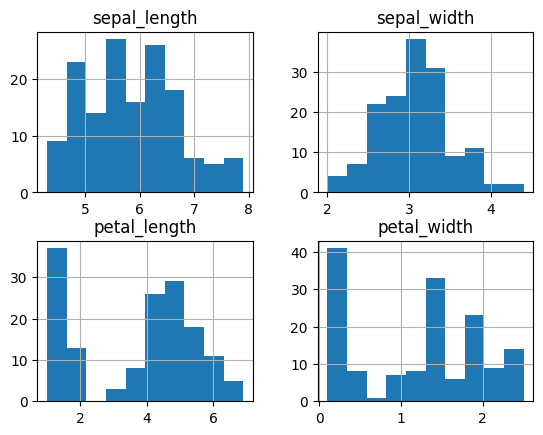

In [54]:
df.hist()

#### Preprocesamiento de datos: Discretización por cuantiles

- Es necesario discretizar las variables continuas del conjunto de datos Iris. Una forma simple es usando binning con cuantiles. 4 categorías puede suele ser un buen punto de partida.

    - La siguiente función discretize_column usa pd.qcut para dividir los datos en k = 4 intervalos aproximadamente iguales, asignando etiquetas 0, 1, 2 y 3.

    - Se aplica esto a cada una de las cuatro variables numéricas, reemplazándolas por valores discretos.

    - Imprime la visualización de los datos discretizados y las categorías únicas para confirmarlo.

In [55]:
# 1. Definir función para discretizar en 4 categorías
def discretize_column(series, n_bins=4):
    labels = list(range(n_bins))
    return pd.qcut(series, q=n_bins, labels=labels)

def robust_discretize_df(df, max_bins=4):
    df_out = df.copy()
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            try:
                unique_vals = df[col].nunique()
                bins = min(max_bins, unique_vals)  # evita más bins que valores únicos
                df_out[col] = pd.qcut(df[col], q=bins, labels=False, duplicates='drop')
            except ValueError:
                print(f"Saltando {col}: no se pudo discretizar (pocos valores únicos)")
    return df_out

# 2. Aplicar discretización a las columnas continuas
df_disc = df.copy()
# Convertir 'class' a valores enteros
for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    df_disc[col] = discretize_column(df_disc[col], n_bins=4)

df_disc['class'] = df_disc['class'].astype('category').cat.codes

'''
# 3. Verificar resultado
print(df_disc[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].head())
print("\nValores únicos por columna:")
print({col: sorted(df_disc[col].unique()) for col in df_disc.columns})
'''
df_disc.head(10)

,sepal_length,sepal_width,petal_length,petal_width,class
0,0,3,0,0,0
1,0,1,0,0,0
2,0,2,0,0,0
3,0,2,0,0,0
4,0,3,0,0,0
5,1,3,1,1,0
6,0,3,0,0,0
7,0,3,0,0,0
8,0,1,0,0,0
9,0,2,0,0,0


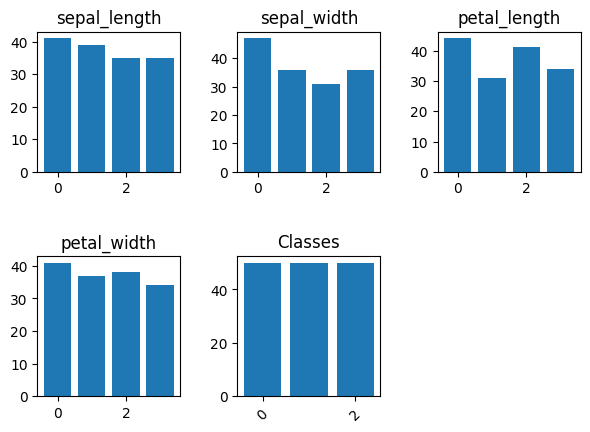

In [11]:
# Calcular cuadrícula de subplots (rectangular, casi cuadrada)
n_cols = math.ceil(math.sqrt(len(df_disc.columns)))
n_rows = math.ceil(len(df_disc.columns) / n_cols)

for col in df_disc.columns:#['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    plt.subplot(n_rows, n_cols , list(df_disc.columns).index(col) + 1)
    plt.bar(df_disc[col].value_counts().index, df_disc[col].value_counts().values)
    #plt.xlabel('Especies')
    #plt.ylabel('Frecuencia')
    plt.tight_layout(pad=2.5)
    plt.subplots_adjust(wspace=0.4, hspace=0.6)
    #plt.show()
    if col == 'class':
        plt.title('Classes')
        plt.xticks(rotation=45)
        #plt.show()
    else:
        plt.title(f'{col}')
        plt.xticks(rotation=0)
        #plt.show()
    # Ajustar el layout para que no se superpongan los subplots 

#### Visualización de población rankeada


Puntuaciones BIC de los individuos:
Individuo 1: -8876.76
[[0 0 0 1 0]
 [1 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Individuo 2: -2348.49
[[0 0 0 1 0]
 [1 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Individuo 3: -6026.94
[[0 0 0 1 0]
 [1 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Individuo 4: -97615.74
[[0 0 0 1 0]
 [1 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Individuo 5: -59698.97
[[0 0 0 1 0]
 [1 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Individuo 6: -261192.17
[[0 0 0 1 0]
 [1 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 0 0 0]]


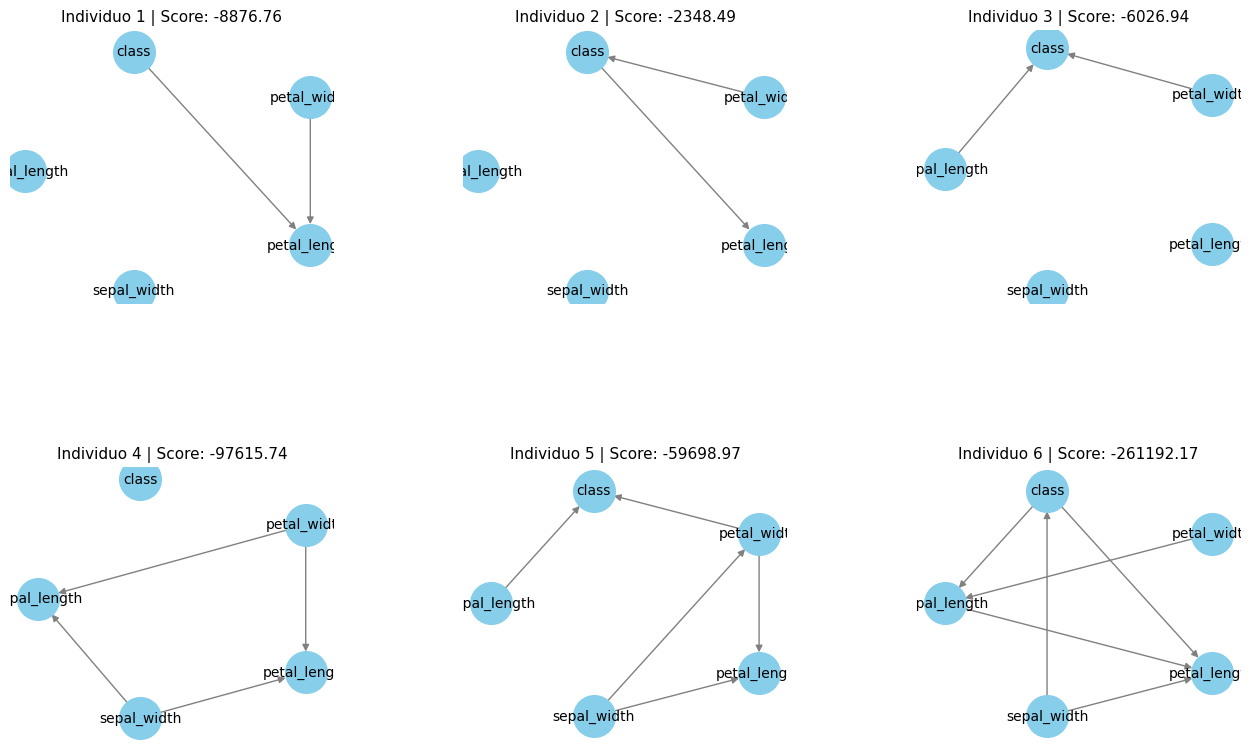

In [63]:
pop_size = 6
n_vars = len(df_disc.columns)
# Generar población inicial de DAGs a partir de las columnas discretizadas
pop = generate_initial_population(pop_size=pop_size, n_vars=n_vars)

'''

for i, ind in enumerate(pop, 1):
    print(f"\nIndividuo {i}:\n{ind}")
'''    
# (Simulación de puntuaciones aleatorias por ahora)
scores = evaluate_population(pop, df)#[bic_score(df, ind) for ind in pop]
claves = [f"Individuo {i+1}" for i in range(len(pop))]
pop_scores = dict(zip(claves, scores))
print("\nPuntuaciones BIC de los individuos:")
for clave, score in pop_scores.items():
    print(f"{clave}: {score:.2f}\n{ind}")
# Visualizar población con puntuaciones BIC
visualize_population2(pop, variable_names=list(df_disc.columns), scores=scores, figsize=(13, 8))

#### Selección de padres

Dos padres seleccionados:
Padre 1: -8876.757470356859 
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]
 [0 0 1 0 0]]
Padre 2: -97615.7448568699 
[[0 0 0 0 0]
 [1 0 1 0 0]
 [0 0 0 0 0]
 [1 0 1 0 0]
 [0 0 0 0 0]]


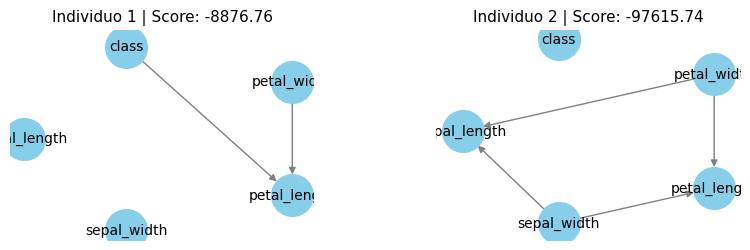

In [64]:
#### # Seleccionar padres basados en BIC
parents = select_parents(pop, scores, n_parents=2)  
pscores = evaluate_population(parents, df)  # Re-evaluar los padres seleccionados
# Mostrar los padres seleccionados
print("Dos padres seleccionados:")
for i, p in enumerate(parents):
    print(f"Padre {i+1}: {pscores[i]} \n{p}")
# Visualizar padres seleccionados
visualize_population2(parents, variable_names=list(df_disc.columns), scores=pscores, figsize=(8, 3))

#### Cruce y descendencia

Es DAG: True


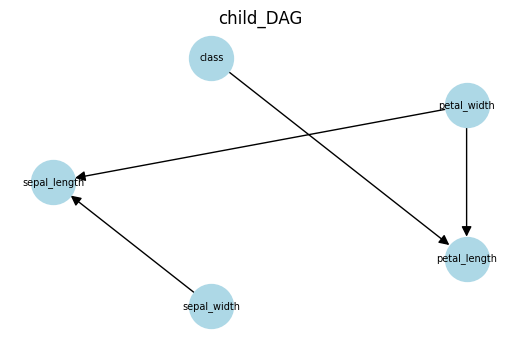

In [86]:
child = crossover_mask(parents[0],parents[1])
# ¿Es acíclico?
print("Es DAG:", is_acyclic(child))
plot_dag(child, variable_names=list(df.columns), title="child_DAG")

#### Mutación 

Es acíclico: True


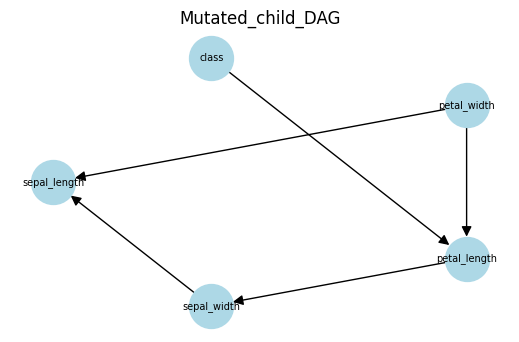

In [89]:
mutated_child = mutate(child, prob_add=0.5, prob_del=0.3)
print("Es acíclico:", is_acyclic(mutated_child))
plot_dag(mutated_child, variable_names=list(df.columns), title="Mutated_child_DAG")

#### Correr ciclo completo con evolve()

Mejor BIC encontrado: -739.2590351779644
Matriz de adyacencia del DAG óptimo:
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 0 0 0 1]
 [0 1 1 0 0]]


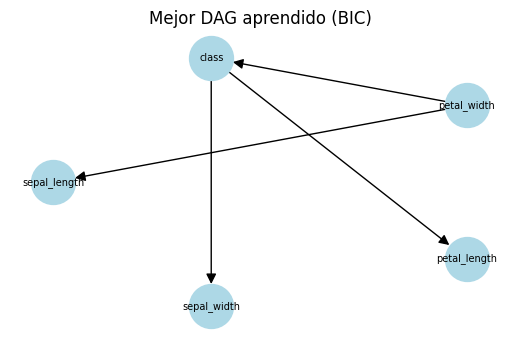

In [108]:
# Ejecutar evolución
best_dag, best_score, history = evolve(
    data=df_disc,                # Datos Iris ya discretizados
    pop_size=10,
    n_generations=20,
    edge_prob=0.3,
    prob_add=0.3,
    prob_del=0.3,
    prob_flip=0.2,
    elite_fraction=0.2,
    verbose=False
)

print("Mejor BIC encontrado:", best_score)
print("Matriz de adyacencia del DAG óptimo:")
print(best_dag)

# Visualizar el mejor DAG
plot_dag(best_dag, variable_names=list(df.columns), title="Mejor DAG aprendido (BIC)")

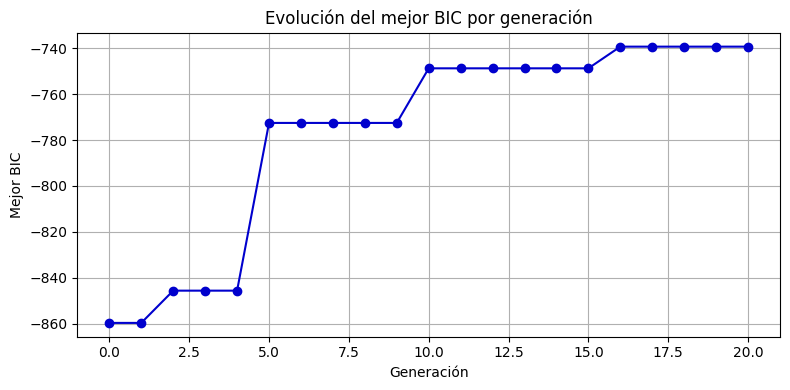

In [109]:
gens, scores = zip(*history)

plt.figure(figsize=(8, 4))
plt.plot(gens, scores, marker='o', color='mediumblue')
plt.title("Evolución del mejor BIC por generación")
plt.xlabel("Generación")
plt.ylabel("Mejor BIC")
plt.grid(True)
plt.tight_layout()
plt.show()

## Datos vote republican democrat.

In [116]:
df_vote = pd.read_csv("DataHNB/vote_dis.csv")
df_vote

,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa,Class
0,n,y,n,y,y,y,n,n,n,y,n,y,y,y,n,y,republican
1,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,y,republican
2,n,y,y,n,y,y,n,n,n,n,y,n,y,y,n,n,democrat
3,n,y,y,n,y,y,n,n,n,n,y,n,y,n,n,y,democrat
4,y,y,y,n,y,y,n,n,n,n,y,n,y,y,y,y,democrat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,n,n,y,y,y,y,n,n,y,y,n,y,y,y,n,y,republican
431,n,n,y,n,n,n,y,y,y,y,n,n,n,n,n,y,democrat
432,n,y,n,y,y,y,n,n,n,n,y,y,y,y,n,y,republican
433,n,n,n,y,y,y,y,y,y,y,n,y,y,y,n,y,republican


In [121]:
#for column in columns.df_vote
for column in df_vote.columns:
    df_vote[column] = df_vote[column].astype('category').cat.codes
df_vote

,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa,Class
0,0,1,0,1,1,1,0,0,0,1,0,1,1,1,0,1,1
1,0,1,0,1,1,1,0,0,0,0,0,1,1,1,0,1,1
2,0,1,1,0,1,1,0,0,0,0,1,0,1,1,0,0,0
3,0,1,1,0,1,1,0,0,0,0,1,0,1,0,0,1,0
4,1,1,1,0,1,1,0,0,0,0,1,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,0,0,1,1,1,1,0,0,1,1,0,1,1,1,0,1,1
431,0,0,1,0,0,0,1,1,1,1,0,0,0,0,0,1,0
432,0,1,0,1,1,1,0,0,0,0,1,1,1,1,0,1,1
433,0,0,0,1,1,1,1,1,1,1,0,1,1,1,0,1,1


Mejor BIC encontrado: -3649.397162140871
Matriz de adyacencia del DAG óptimo:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0]
 [0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0]
 [0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1]
 [0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0]]


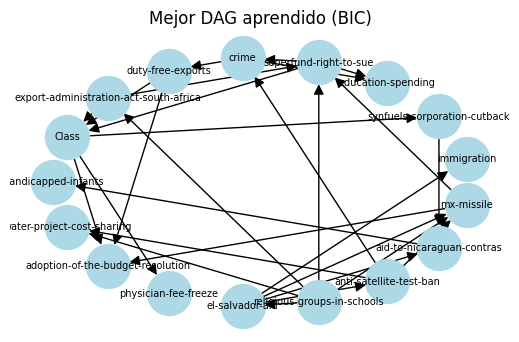

In [130]:
# Ejecutar evolución
best_dag, best_score, history = evolve(
    data=df_vote,                # Datos ya discretizados
    pop_size=10,
    n_generations=20,
    edge_prob=0.3,
    prob_add=0.3,
    prob_del=0.3,
    prob_flip=0.2,
    elite_fraction=0.2,
    verbose=False
)

print("Mejor BIC encontrado:", best_score)
print("Matriz de adyacencia del DAG óptimo:")
print(best_dag)

# Visualizar el mejor DAG
plot_dag(best_dag, variable_names=list(df_vote.columns), title="Mejor DAG aprendido (BIC)")

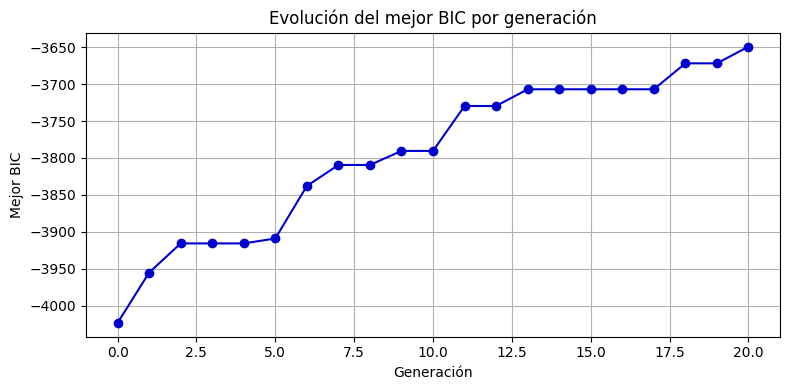

In [131]:
gens, scores = zip(*history)

plt.figure(figsize=(8, 4))
plt.plot(gens, scores, marker='o', color='mediumblue')
plt.title("Evolución del mejor BIC por generación")
plt.xlabel("Generación")
plt.ylabel("Mejor BIC")
plt.grid(True)
plt.tight_layout()
plt.show()

## Datos segments

In [124]:
df_seg = pd.read_csv("DataHNB/segment_cleaned.csv")
df_seg

,region-centroid-col,region-centroid-row,short-line-density-5,short-line-density-2,vedge-mean,vegde-sd,hedge-mean,hedge-sd,intensity-mean,rawred-mean,rawblue-mean,rawgreen-mean,exred-mean,exblue-mean,exgreen-mean,value-mean,saturation-mean,hue-mean,class
0,2,8,1,1,1,1,2,1,3,2,3,2,7,4,5,3,3,2,path
1,1,8,1,1,1,1,1,1,2,1,2,2,7,2,8,2,4,10,grass
2,2,6,1,1,1,1,1,1,1,1,1,1,9,2,6,1,8,2,foliage
3,3,9,1,1,2,1,1,1,1,1,1,1,8,1,8,1,5,9,grass
4,7,6,1,1,1,1,1,1,1,1,1,1,9,2,6,1,10,3,window
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305,9,5,1,1,1,1,1,1,1,1,1,1,8,3,6,1,10,2,foliage
2306,2,3,1,1,1,1,1,1,8,7,9,8,2,8,4,9,3,2,sky
2307,10,2,1,1,1,1,1,1,9,9,10,9,3,7,3,10,3,2,sky
2308,9,3,1,1,1,1,1,1,3,3,4,3,7,4,4,4,3,2,cement


In [126]:
df_seg["class"] = df_seg["class"].astype('category').cat.codes
df_seg

,region-centroid-col,region-centroid-row,short-line-density-5,short-line-density-2,vedge-mean,vegde-sd,hedge-mean,hedge-sd,intensity-mean,rawred-mean,rawblue-mean,rawgreen-mean,exred-mean,exblue-mean,exgreen-mean,value-mean,saturation-mean,hue-mean,class
0,2,8,1,1,1,1,2,1,3,2,3,2,7,4,5,3,3,2,4
1,1,8,1,1,1,1,1,1,2,1,2,2,7,2,8,2,4,10,3
2,2,6,1,1,1,1,1,1,1,1,1,1,9,2,6,1,8,2,2
3,3,9,1,1,2,1,1,1,1,1,1,1,8,1,8,1,5,9,3
4,7,6,1,1,1,1,1,1,1,1,1,1,9,2,6,1,10,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305,9,5,1,1,1,1,1,1,1,1,1,1,8,3,6,1,10,2,2
2306,2,3,1,1,1,1,1,1,8,7,9,8,2,8,4,9,3,2,5
2307,10,2,1,1,1,1,1,1,9,9,10,9,3,7,3,10,3,2,5
2308,9,3,1,1,1,1,1,1,3,3,4,3,7,4,4,4,3,2,1


Mejor BIC encontrado: -53974.239887083764
Matriz de adyacencia del DAG óptimo:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


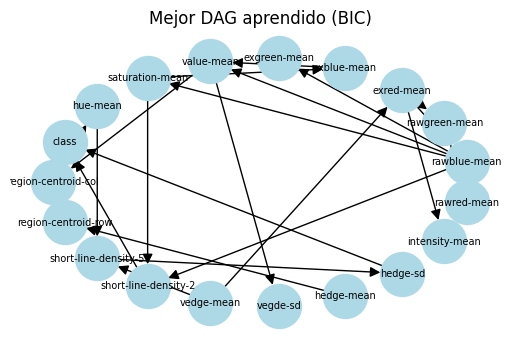

In [128]:
# Ejecutar evolución
best_dag, best_score, history = evolve(
    data=df_seg,                # Datos  ya discretizados
    pop_size=10,
    n_generations=20,
    edge_prob=0.3,
    prob_add=0.3,
    prob_del=0.3,
    prob_flip=0.2,
    elite_fraction=0.2,
    verbose=False
)

print("Mejor BIC encontrado:", best_score)
print("Matriz de adyacencia del DAG óptimo:")
print(best_dag)

# Visualizar el mejor DAG
plot_dag(best_dag, variable_names=list(df_seg.columns), title="Mejor DAG aprendido (BIC)")

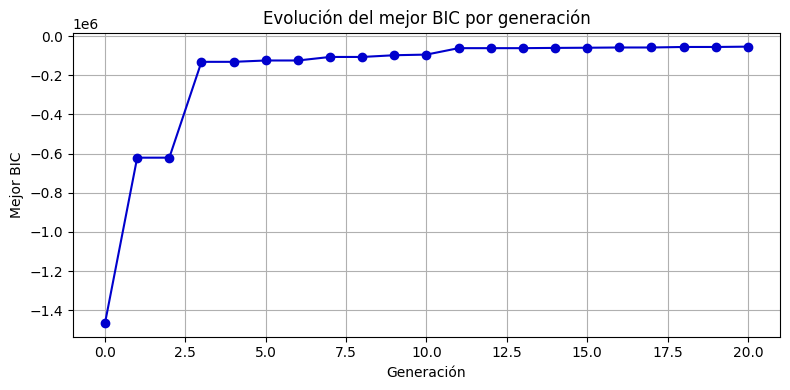

In [129]:
gens, scores = zip(*history)

plt.figure(figsize=(8, 4))
plt.plot(gens, scores, marker='o', color='mediumblue')
plt.title("Evolución del mejor BIC por generación")
plt.xlabel("Generación")
plt.ylabel("Mejor BIC")
plt.grid(True)
plt.tight_layout()
plt.show()

## Datos  Bean

In [133]:
df_bean = pd.read_csv("DataHNB\soybean_dis.csv")
df_bean

,plant-stand,precip,temp,hail,crop-hist,area-damaged,severity,seed-tmt,germination,plant-growth,...,sclerotia,fruit-pods,fruit-spots,seed,mold-growth,seed-discolor,seed-size,shriveling,roots,class
0,normal,gt-norm,norm,yes,same-lst-yr,low-areas,pot-severe,none,90-100,abnorm,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
1,normal,gt-norm,norm,yes,same-lst-two-yrs,scattered,severe,fungicide,80-89,abnorm,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
2,normal,gt-norm,norm,yes,same-lst-yr,scattered,severe,fungicide,lt-80,abnorm,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
3,normal,gt-norm,norm,yes,same-lst-yr,scattered,severe,none,80-89,abnorm,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
4,normal,gt-norm,norm,yes,same-lst-two-yrs,scattered,pot-severe,none,lt-80,abnorm,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,normal,gt-norm,norm,yes,same-lst-two-yrs,upper-areas,pot-severe,none,80-89,norm,...,absent,norm,absent,norm,absent,absent,norm,absent,norm,2-4-d-injury
679,lt-normal,gt-norm,lt-norm,yes,diff-lst-year,scattered,pot-severe,none,80-89,abnorm,...,absent,dna,absent,norm,absent,absent,norm,absent,rotted,herbicide-injury
680,lt-normal,gt-norm,lt-norm,yes,diff-lst-year,scattered,pot-severe,none,80-89,abnorm,...,absent,dna,absent,norm,absent,absent,norm,absent,rotted,herbicide-injury
681,lt-normal,gt-norm,lt-norm,yes,same-lst-yr,whole-field,pot-severe,none,80-89,abnorm,...,absent,dna,absent,norm,absent,absent,norm,absent,rotted,herbicide-injury


In [134]:
#for column in columns.df_vote
for column in df_bean.columns:
    df_bean[column] = df_bean[column].astype('category').cat.codes
df_bean

,plant-stand,precip,temp,hail,crop-hist,area-damaged,severity,seed-tmt,germination,plant-growth,...,sclerotia,fruit-pods,fruit-spots,seed,mold-growth,seed-discolor,seed-size,shriveling,roots,class
0,1,0,2,1,3,0,1,1,1,0,...,0,3,3,1,0,0,1,0,1,10
1,1,0,2,1,2,1,2,0,0,0,...,0,3,3,1,0,0,1,0,1,10
2,1,0,2,1,3,1,2,0,2,0,...,0,3,3,1,0,0,1,0,1,10
3,1,0,2,1,3,1,2,1,0,0,...,0,3,3,1,0,0,1,0,1,10
4,1,0,2,1,2,1,1,1,2,0,...,0,3,3,1,0,0,1,0,1,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,1,0,2,1,2,2,1,1,0,1,...,0,3,0,1,0,0,1,0,1,0
679,0,0,1,1,0,1,1,1,0,0,...,0,1,0,1,0,0,1,0,2,13
680,0,0,1,1,0,1,1,1,0,0,...,0,1,0,1,0,0,1,0,2,13
681,0,0,1,1,3,3,1,1,0,0,...,0,1,0,1,0,0,1,0,2,13


Mejor BIC encontrado: -15656.430636558762
Matriz de adyacencia del DAG óptimo:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


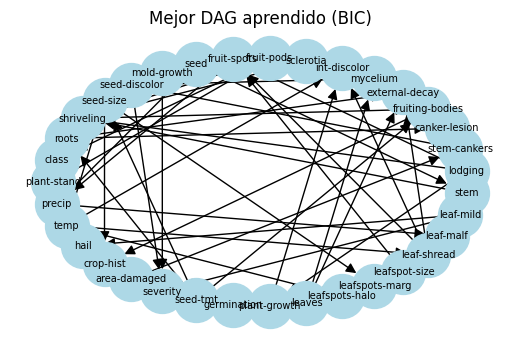

In [135]:
# Ejecutar evolución
best_dag, best_score, history = evolve(
    data=df_bean,                # Datos  ya discretizados
    pop_size=10,
    n_generations=20,
    edge_prob=0.3,
    prob_add=0.3,
    prob_del=0.3,
    prob_flip=0.2,
    elite_fraction=0.2,
    verbose=False
)

print("Mejor BIC encontrado:", best_score)
print("Matriz de adyacencia del DAG óptimo:")
print(best_dag)

# Visualizar el mejor DAG
plot_dag(best_dag, variable_names=list(df_bean.columns), title="Mejor DAG aprendido (BIC)")

## Datos Primary Tumor

In [136]:
df_tumor = pd.read_csv("DataHNB/primary_tumor_cleaned.csv")
df_tumor

,age,sex,histologic-type,degree-of-diffe,bone,bone-marrow,lung,pleura,peritoneum,liver,brain,skin,neck,supraclavicular,axillar,mediastinum,abdominal,class
0,1,1,5,10,10,10,1,10,10,10,10,10,10,10,10,10,10,1
1,1,1,5,10,10,10,10,10,10,1,10,10,10,1,10,1,10,1
2,1,10,5,10,1,10,10,10,10,10,10,10,10,10,10,1,10,1
3,1,10,5,10,1,10,1,1,10,10,10,10,10,10,10,1,10,1
4,1,10,5,10,1,10,1,1,10,10,10,10,10,10,10,1,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,5,10,5,7,10,10,10,10,10,10,10,10,10,10,1,10,10,22
335,5,10,5,7,10,10,10,10,10,10,10,10,10,10,1,10,10,22
336,5,10,5,7,1,10,10,10,10,10,10,10,10,1,1,10,10,22
337,10,10,5,5,10,10,10,10,10,10,10,10,1,1,1,10,10,22


Mejor BIC encontrado: -4128.758413665228
Matriz de adyacencia del DAG óptimo:
[[0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0]]


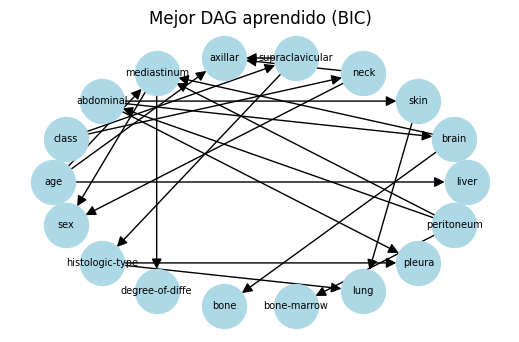

In [138]:
# Ejecutar evolución
best_dag, best_score, history = evolve(
    data=df_tumor,                # Datos  ya discretizados
    pop_size=10,
    n_generations=20,
    edge_prob=0.3,
    prob_add=0.3,
    prob_del=0.3,
    prob_flip=0.2,
    elite_fraction=0.2,
    verbose=False
)

print("Mejor BIC encontrado:", best_score)
print("Matriz de adyacencia del DAG óptimo:")
print(best_dag)

# Visualizar el mejor DAG
plot_dag(best_dag, variable_names=list(df_tumor.columns), title="Mejor DAG aprendido (BIC)")

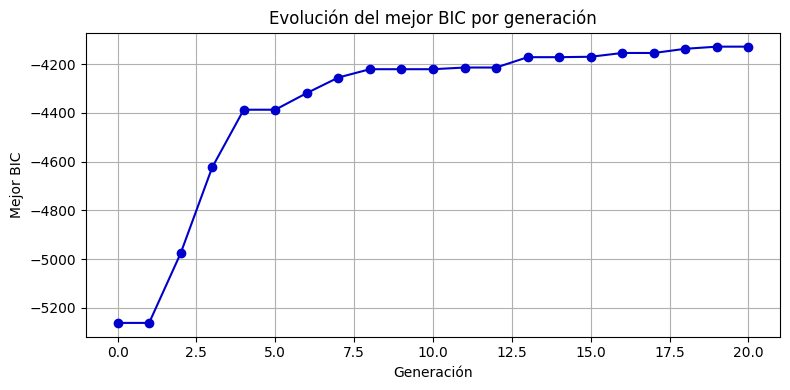

In [139]:
gens, scores = zip(*history)

plt.figure(figsize=(8, 4))
plt.plot(gens, scores, marker='o', color='mediumblue')
plt.title("Evolución del mejor BIC por generación")
plt.xlabel("Generación")
plt.ylabel("Mejor BIC")
plt.grid(True)
plt.tight_layout()
plt.show()

## Datos lympho

In [140]:
df_lympho = pd.read_csv("DataHNB/primary_tumor_cleaned.csv")
df_lympho

,age,sex,histologic-type,degree-of-diffe,bone,bone-marrow,lung,pleura,peritoneum,liver,brain,skin,neck,supraclavicular,axillar,mediastinum,abdominal,class
0,1,1,5,10,10,10,1,10,10,10,10,10,10,10,10,10,10,1
1,1,1,5,10,10,10,10,10,10,1,10,10,10,1,10,1,10,1
2,1,10,5,10,1,10,10,10,10,10,10,10,10,10,10,1,10,1
3,1,10,5,10,1,10,1,1,10,10,10,10,10,10,10,1,10,1
4,1,10,5,10,1,10,1,1,10,10,10,10,10,10,10,1,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,5,10,5,7,10,10,10,10,10,10,10,10,10,10,1,10,10,22
335,5,10,5,7,10,10,10,10,10,10,10,10,10,10,1,10,10,22
336,5,10,5,7,1,10,10,10,10,10,10,10,10,1,1,10,10,22
337,10,10,5,5,10,10,10,10,10,10,10,10,1,1,1,10,10,22


Mejor BIC encontrado: -4074.602094731666
Matriz de adyacencia del DAG óptimo:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


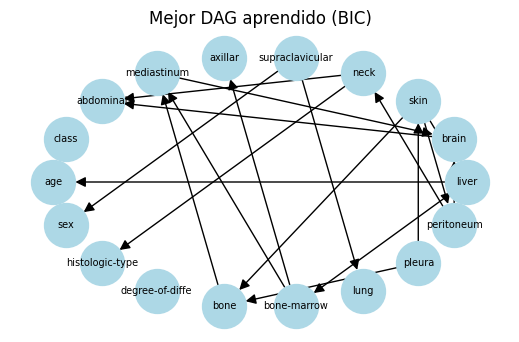

In [141]:
# Ejecutar evolución
best_dag, best_score, history = evolve(
    data=df_lympho,                # Datos  ya discretizados
    pop_size=10,
    n_generations=20,
    edge_prob=0.3,
    prob_add=0.3,
    prob_del=0.3,
    prob_flip=0.2,
    elite_fraction=0.2,
    verbose=False
)

print("Mejor BIC encontrado:", best_score)
print("Matriz de adyacencia del DAG óptimo:")
print(best_dag)

# Visualizar el mejor DAG
plot_dag(best_dag, variable_names=list(df_lympho.columns), title="Mejor DAG aprendido (BIC)")

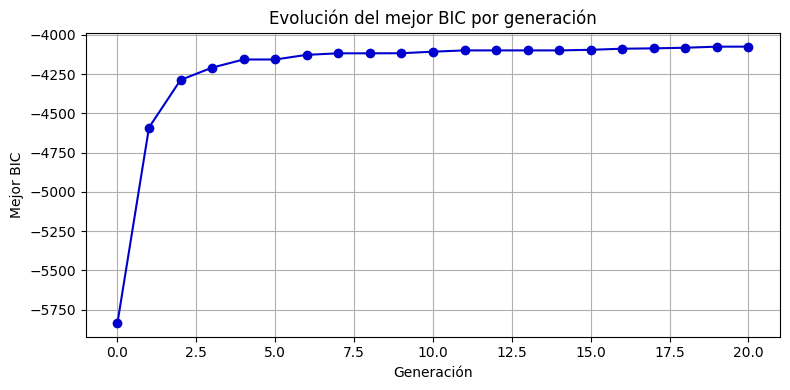

In [142]:
gens, scores = zip(*history)

plt.figure(figsize=(8, 4))
plt.plot(gens, scores, marker='o', color='mediumblue')
plt.title("Evolución del mejor BIC por generación")
plt.xlabel("Generación")
plt.ylabel("Mejor BIC")
plt.grid(True)
plt.tight_layout()
plt.show()

## Datos Letter

In [147]:
df_letter = pd.read_csv("DataHNB/letter_cleaned.csv")
df_letter

,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx,class
0,2,6,2,4,1,6,9,1,4,4,7,6,1,6,1,6,T
1,4,8,2,5,2,7,4,4,3,9,2,6,2,6,3,7,I
2,3,8,4,6,4,7,4,2,4,7,2,5,2,5,2,6,D
3,5,8,4,4,2,4,6,3,4,3,3,7,4,7,2,6,N
4,2,1,2,1,1,6,4,4,4,4,4,6,1,5,4,7,G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2,2,2,2,2,5,5,5,4,4,4,3,2,6,2,5,D
19996,5,7,6,6,3,3,6,4,6,8,6,9,2,6,2,5,C
19997,4,6,4,5,4,4,8,2,5,8,6,4,2,8,2,3,T
19998,2,2,3,2,1,6,5,2,4,7,4,6,1,6,4,6,S


In [148]:
df_letter["class"] = df_letter["class"].astype('category').cat.codes
df_letter

,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx,class
0,2,6,2,4,1,6,9,1,4,4,7,6,1,6,1,6,19
1,4,8,2,5,2,7,4,4,3,9,2,6,2,6,3,7,8
2,3,8,4,6,4,7,4,2,4,7,2,5,2,5,2,6,3
3,5,8,4,4,2,4,6,3,4,3,3,7,4,7,2,6,13
4,2,1,2,1,1,6,4,4,4,4,4,6,1,5,4,7,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2,2,2,2,2,5,5,5,4,4,4,3,2,6,2,5,3
19996,5,7,6,6,3,3,6,4,6,8,6,9,2,6,2,5,2
19997,4,6,4,5,4,4,8,2,5,8,6,4,2,8,2,3,19
19998,2,2,3,2,1,6,5,2,4,7,4,6,1,6,4,6,18


Mejor BIC encontrado: -565421.8859641486
Matriz de adyacencia del DAG óptimo:
[[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]]


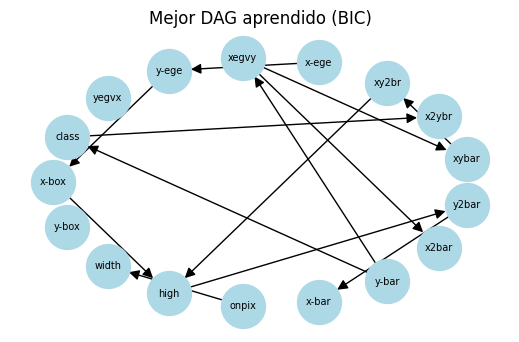

In [149]:
# Ejecutar evolución
best_dag, best_score, history = evolve(
    data=df_letter,                # Datos  ya discretizados
    pop_size=10,
    n_generations=20,
    edge_prob=0.3,
    prob_add=0.3,
    prob_del=0.3,
    prob_flip=0.2,
    elite_fraction=0.2,
    verbose=False
)

print("Mejor BIC encontrado:", best_score)
print("Matriz de adyacencia del DAG óptimo:")
print(best_dag)

# Visualizar el mejor DAG
plot_dag(best_dag, variable_names=list(df_letter.columns), title="Mejor DAG aprendido (BIC)")

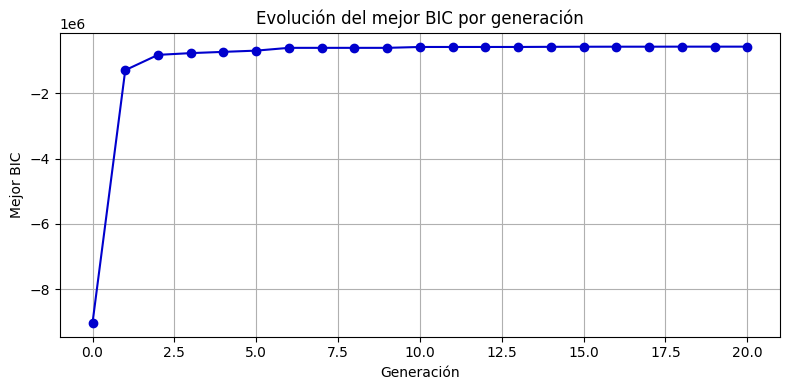

In [151]:
gens, scores = zip(*history)

plt.figure(figsize=(8, 4))
plt.plot(gens, scores, marker='o', color='mediumblue')
plt.title("Evolución del mejor BIC por generación")
plt.xlabel("Generación")
plt.ylabel("Mejor BIC")
plt.grid(True)
plt.tight_layout()
plt.show()

## Datos Labor

In [154]:
df_labor = pd.read_csv("DataHNB/labor_cleaned.csv")
df_labor.head(7)

,duration,wage-increase-first-year,wage-increase-second-year,wage-increase-third-year,cost-of-living-adjustment,working-hours,pension,standby-pay,shift-differential,education-allowance,statutory-holidays,vacation,longterm-disability-assistance,contribution-to-dental-plan,bereavement-assistance,contribution-to-health-plan,class
0,1,6,4,7,none,10,empl_contr,5,1,no,4,average,yes,half,yes,full,good
1,5,5,8,7,none,7,ret_allw,5,2,yes,4,below_average,yes,full,yes,full,good
2,6,4,4,7,none,9,empl_contr,5,2,no,4,generous,yes,half,yes,half,good
3,10,4,4,10,tc,9,empl_contr,5,2,yes,4,below_average,yes,half,yes,full,good
4,10,5,5,10,none,10,empl_contr,5,2,no,5,average,yes,half,yes,half,good
5,5,1,1,7,none,7,empl_contr,5,3,yes,5,average,yes,half,yes,full,good
6,10,4,6,10,tc,9,empl_contr,5,2,no,5,generous,yes,none,yes,half,good


In [157]:
for column in df_labor.columns:
    df_labor[column] = df_labor[column].astype('category').cat.codes
df_labor.head(7)

,duration,wage-increase-first-year,wage-increase-second-year,wage-increase-third-year,cost-of-living-adjustment,working-hours,pension,standby-pay,shift-differential,education-allowance,statutory-holidays,vacation,longterm-disability-assistance,contribution-to-dental-plan,bereavement-assistance,contribution-to-health-plan,class
0,0,5,3,2,0,5,0,2,0,0,2,0,1,1,1,0,1
1,1,4,7,2,0,2,2,2,1,1,2,1,1,0,1,0,1
2,2,3,3,2,0,4,0,2,1,0,2,2,1,1,1,1,1
3,3,3,3,4,1,4,0,2,1,1,2,1,1,1,1,0,1
4,3,4,4,4,0,5,0,2,1,0,3,0,1,1,1,1,1
5,1,0,0,2,0,2,0,2,2,1,3,0,1,1,1,0,1
6,3,3,5,4,1,4,0,2,1,0,3,2,1,2,1,1,1


Mejor BIC encontrado: -1061.5074933734663
Matriz de adyacencia del DAG óptimo:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0]]


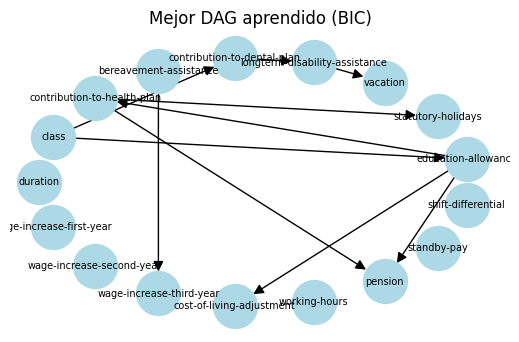

In [158]:
# Ejecutar evolución
best_dag, best_score, history = evolve(
    data=df_labor,                # Datos  ya discretizados
    pop_size=10,
    n_generations=20,
    edge_prob=0.3,
    prob_add=0.3,
    prob_del=0.3,
    prob_flip=0.2,
    elite_fraction=0.2,
    verbose=False
)

print("Mejor BIC encontrado:", best_score)
print("Matriz de adyacencia del DAG óptimo:")
print(best_dag)

# Visualizar el mejor DAG
plot_dag(best_dag, variable_names=list(df_labor.columns), title="Mejor DAG aprendido (BIC)")

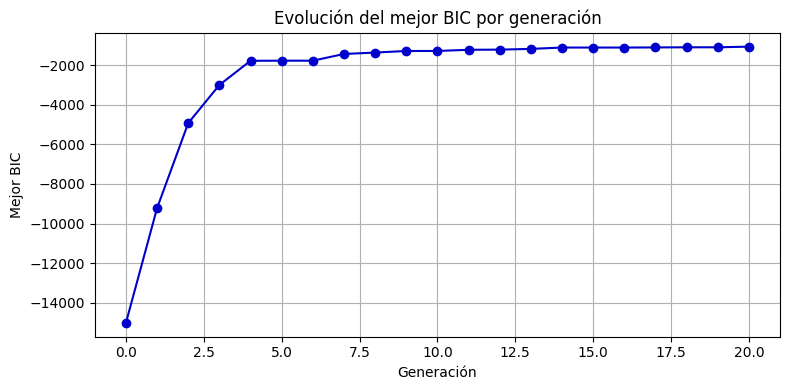

In [159]:
gens, scores = zip(*history)

plt.figure(figsize=(8, 4))
plt.plot(gens, scores, marker='o', color='mediumblue')
plt.title("Evolución del mejor BIC por generación")
plt.xlabel("Generación")
plt.ylabel("Mejor BIC")
plt.grid(True)
plt.tight_layout()
plt.show()

## Datos Ionosphere

In [167]:
df_ionosphere = pd.read_csv("DataHNB/ionosphere_cleaned.csv")
df_ionosphere.head(7)

,a01,a03,a04,a05,a06,a07,a08,a09,a10,a11,...,a26,a27,a28,a29,a30,a31,a32,a33,a34,class
0,10,10,5,10,6,10,4,10,6,10,...,3,8,3,7,4,8,3,6,3,g
1,10,10,5,10,4,5,1,10,5,8,...,4,4,5,5,5,5,5,5,5,b
2,10,10,5,10,6,10,5,10,6,9,...,3,8,4,8,5,9,4,8,4,g
3,10,10,3,10,10,9,1,5,5,5,...,10,8,10,10,4,7,10,4,10,b
4,10,10,5,10,6,10,4,9,5,8,...,2,6,3,6,2,5,3,5,2,g
5,10,6,5,5,5,5,5,6,6,6,...,5,5,6,5,6,5,5,5,6,b
6,10,10,5,10,4,10,4,10,4,9,...,1,6,1,6,1,5,1,5,1,g


In [168]:
df_ionosphere["class"] = df_ionosphere["class"].astype('category').cat.codes
df_ionosphere

,a01,a03,a04,a05,a06,a07,a08,a09,a10,a11,...,a26,a27,a28,a29,a30,a31,a32,a33,a34,class
0,10,10,5,10,6,10,4,10,6,10,...,3,8,3,7,4,8,3,6,3,1
1,10,10,5,10,4,5,1,10,5,8,...,4,4,5,5,5,5,5,5,5,0
2,10,10,5,10,6,10,5,10,6,9,...,3,8,4,8,5,9,4,8,4,1
3,10,10,3,10,10,9,1,5,5,5,...,10,8,10,10,4,7,10,4,10,0
4,10,10,5,10,6,10,4,9,5,8,...,2,6,3,6,2,5,3,5,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,10,10,6,9,5,10,5,10,5,10,...,5,10,6,10,6,10,5,10,5,1
347,10,10,6,10,5,10,5,10,6,10,...,6,10,6,10,6,10,5,10,6,1
348,10,10,5,10,5,10,5,10,6,10,...,6,10,6,10,6,10,6,10,5,1
349,10,10,5,10,5,10,5,10,6,10,...,5,10,5,10,5,10,5,10,5,1


Mejor BIC encontrado: 49064233008.346275
Matriz de adyacencia del DAG óptimo:
[[0 0 0 ... 0 0 1]
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [1 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


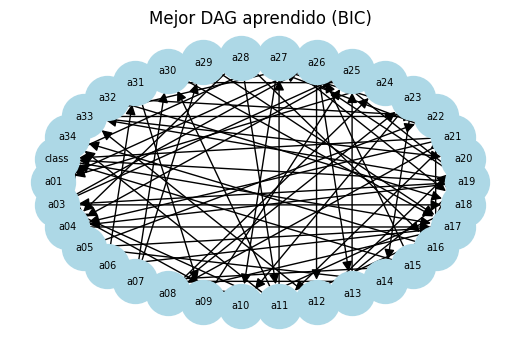

In [178]:
# Ejecutar evolución
best_dag, best_score, history = evolve(
    data=df_ionosphere,                # Datos Iris ya discretizados
    pop_size=10,
    n_generations=20,
    edge_prob=0.3,
    prob_add=0.3,
    prob_del=0.3,
    prob_flip=0.2,
    elite_fraction=0.2,
    verbose=False
)

print("Mejor BIC encontrado:", best_score)
print("Matriz de adyacencia del DAG óptimo:")
print(best_dag)

# Visualizar el mejor DAG
plot_dag(best_dag, variable_names=list(df_ionosphere.columns), title="Mejor DAG aprendido (BIC)")

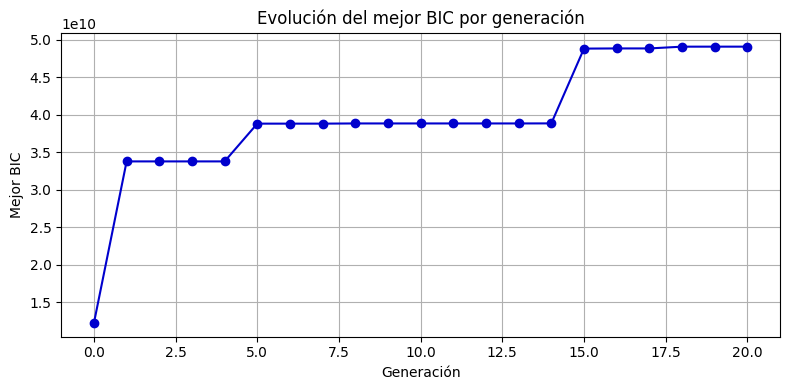

In [179]:
gens, scores = zip(*history)

plt.figure(figsize=(8, 4))
plt.plot(gens, scores, marker='o', color='mediumblue')
plt.title("Evolución del mejor BIC por generación")
plt.xlabel("Generación")
plt.ylabel("Mejor BIC")
plt.grid(True)
plt.tight_layout()
plt.show()

## Datos Diabetes

In [170]:
df_diabetes = pd.read_csv("DataHNB/diabetes_cleaned.csv")
df_diabetes.head(7)

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,4,8,6,4,1,6,3,5,tested_positive
1,1,5,6,3,1,4,2,2,tested_negative
2,5,10,6,1,1,4,3,2,tested_positive
3,1,5,6,3,2,5,1,1,tested_negative
4,1,7,4,4,2,7,10,2,tested_positive
5,3,6,7,1,1,4,1,2,tested_negative
6,2,4,5,4,2,5,1,1,tested_positive


In [171]:
df_diabetes["class"] = df_diabetes["class"].astype('category').cat.codes
df_diabetes

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,4,8,6,4,1,6,3,5,1
1,1,5,6,3,1,4,2,2,0
2,5,10,6,1,1,4,3,2,1
3,1,5,6,3,2,5,1,1,0
4,1,7,4,4,2,7,10,2,1
...,...,...,...,...,...,...,...,...,...
763,6,6,7,5,3,5,1,7,0
764,2,7,6,3,1,6,2,1,0
765,3,7,6,3,2,4,1,2,0
766,1,7,5,1,1,5,2,5,1


Mejor BIC encontrado: -757.2712044226575
Matriz de adyacencia del DAG óptimo:
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 0 0 0]
 [1 0 1 1 0]]


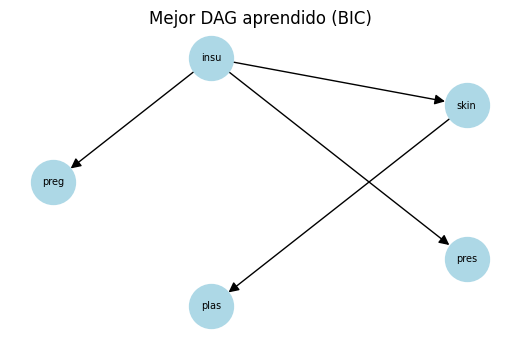

In [174]:
# Ejecutar evolución
best_dag, best_score, history = evolve(
    data=df_disc,                # Datos Iris ya discretizados
    pop_size=10,
    n_generations=20,
    edge_prob=0.3,
    prob_add=0.3,
    prob_del=0.3,
    prob_flip=0.2,
    elite_fraction=0.2,
    verbose=False
)

print("Mejor BIC encontrado:", best_score)
print("Matriz de adyacencia del DAG óptimo:")
print(best_dag)

# Visualizar el mejor DAG
plot_dag(best_dag, variable_names=list(df_diabetes.columns), title="Mejor DAG aprendido (BIC)")

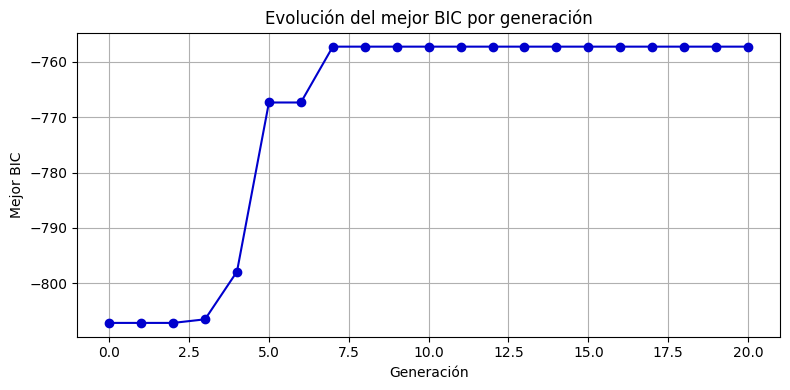

In [175]:
gens, scores = zip(*history)

plt.figure(figsize=(8, 4))
plt.plot(gens, scores, marker='o', color='mediumblue')
plt.title("Evolución del mejor BIC por generación")
plt.xlabel("Generación")
plt.ylabel("Mejor BIC")
plt.grid(True)
plt.tight_layout()
plt.show()